# 📋 Insights Estratégicos y Recomendaciones Ejecutivas — Nivel Senior Empresarial
## Proyecto: *Conociendo al Cliente 360°* — InsightReach Analytics
### Notebook 05: Síntesis, Recomendaciones y Roadmap de Implementación

---

| Campo | Detalle |
|-------|--------|
| **👤 Autor** | Dody Dueñas |
| **📅 Fecha** | Abril 2026 |
| **🎯 Versión** | 2.0 — Estándar Senior Empresarial |
| **📥 Input** | Todos los datos procesados + modelos entrenados |
| **📤 Output** | Reporte ejecutivo + visualizaciones de síntesis |

---

## 🎯 Propósito de este Notebook

Este es el **notebook de conclusión del proyecto**. Su audiencia no es técnica — está diseñado para ser presentado ante la **dirección de InsightReach Analytics** y los **stakeholders** del proyecto.

Transformamos **datos → insights → decisiones de negocio**, respondiendo las tres preguntas estratégicas que motivaron este proyecto:

> 1. **¿Quiénes son nuestros clientes?** → Perfiles estadísticos y segmentos
> 2. **¿Qué quieren y qué podemos predecir?** → Preferencias y modelo predictivo
> 3. **¿Dónde están las oportunidades?** → Gaps, nichos y prioridades geográficas

---

## 🗺️ Estructura del Reporte Ejecutivo

| # | Sección | Contenido |
|---|---------|----------|
| **1** | KPIs del Negocio | Dashboard de métricas clave del dataset |
| **2** | Perfiles de Segmentos | Caracterización de cada cluster con estrategia |
| **3** | Oportunidades de Mercado | Análisis Yelp: brechas y nichos |
| **4** | Recomendaciones Estratégicas | Plan accionable por prioridad |
| **5** | Roadmap de Implementación | Timeline 12 meses + KPIs de seguimiento |
| **6** | ROI Proyectado | Estimación de impacto económico |

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 1: CONFIGURACIÓN Y CARGA DE RESULTADOS                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
sns.set_context('notebook', font_scale=1.1)

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#A23B72',
    'accent':    '#F18F01',
    'success':   '#2DC653',
    'danger':    '#E84855',
    'neutral':   '#6c757d',
    'gold':      '#FFD700',
    'dark':      '#1a1a2e',
}

plt.rcParams.update({
    'figure.figsize': (16, 9), 'figure.dpi': 100,
    'savefig.dpi': 300, 'axes.titlesize': 14,
    'axes.titleweight': 'bold', 'axes.labelsize': 12,
})

sys.path.insert(0, '..')
# --- Deteccion robusta de la raiz del proyecto ---
import os
from pathlib import Path
try:
    current_path = Path(os.path.abspath('')).resolve()
except:
    current_path = Path(__file__).parent.resolve()

if (current_path / 'notebooks').exists():
    ROOT_DIR = current_path
elif (current_path.parent / 'notebooks').exists():
    ROOT_DIR = current_path.parent
else:
    ROOT_DIR = Path(r"c:\Users\DODY DUEÑAS\Documents\ProyectodeHenry\Proyecto_Integrador_Dody_Empresarial")

DATA_RAW       = ROOT_DIR / 'data' / 'raw'
DATA_PROCESSED = ROOT_DIR / 'data' / 'processed'
DATA_EXTERNAL  = ROOT_DIR / 'data' / 'external'
REPORTS_FIGS   = ROOT_DIR / 'reports' / 'figures'
REPORTS_TABS   = ROOT_DIR / 'reports' / 'tables'
MODELS_DIR     = ROOT_DIR / 'models'
REPORTS_DIR    = ROOT_DIR / 'reports'

# Crear directorios si no existen
for p in [DATA_PROCESSED, DATA_EXTERNAL, REPORTS_FIGS, REPORTS_TABS]:
    p.mkdir(parents=True, exist_ok=True)
# ── Carga robusta de todos los outputs del pipeline ───────────────────────────
print('\n' + '═' * 75)
print('  📥 CARGANDO RESULTADOS DE TODOS LOS NOTEBOOKS')
print('═' * 75)

datasets = {}

# Rutas de archivos
clusters_path   = DATA_PROCESSED / 'customers_with_clusters.csv'
features_path   = DATA_PROCESSED / 'customers_features.csv'
clean_path      = DATA_PROCESSED / 'customers_clean.csv'
yelp_path       = DATA_PROCESSED / 'yelp_clean.csv'
market_path     = DATA_PROCESSED / 'market_comparison.csv'
sel_features_path = DATA_PROCESSED / 'selected_features.joblib'
model_comp_path = REPORTS_TABS / 'model_comparison.csv'

# Cargar datasets
for nombre, path in [
    ('clusters',  clusters_path),
    ('features',  features_path),
    ('clean',     clean_path),
    ('yelp',      yelp_path),
    ('market',    market_path),
]:
    if path.exists():
        try:
            kws = {'index_col': 0} if nombre == 'market' else {}
            datasets[nombre] = pd.read_csv(path, low_memory=False, **kws)
            print(f'  ✅ {nombre:<12}: {len(datasets[nombre]):,} registros')
        except Exception as e:
            print(f'  ⚠️  {nombre:<12}: Error — {e}')
    else:
        print(f'  ❌ {nombre:<12}: No encontrado — {path.name}')

# Usar el dataset principal disponible
df = datasets.get('clusters', datasets.get('features', datasets.get('clean')))
if df is None:
    raise RuntimeError('❌ No hay ningún dataset disponible. Ejecute los notebooks 01-04.')

# Cargar features seleccionadas
selected_features = joblib.load(sel_features_path) if sel_features_path.exists() else []

# Cargar comparación de modelos
df_model_comp = pd.read_csv(model_comp_path) if model_comp_path.exists() else pd.DataFrame()

print(f'\n  ✅ Dataset principal: {len(df):,} clientes × {len(df.columns)} columnas')
print(f'  📅 Reporte generado  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')



═══════════════════════════════════════════════════════════════════════════
  📥 CARGANDO RESULTADOS DE TODOS LOS NOTEBOOKS
═══════════════════════════════════════════════════════════════════════════


  ✅ clusters    : 30,000 registros
  ✅ features    : 30,000 registros


  ✅ clean       : 30,000 registros
  ✅ yelp        : 463 registros
  ✅ market      : 10 registros

  ✅ Dataset principal: 30,000 clientes × 53 columnas
  📅 Reporte generado  : 2026-04-09 12:58:56


---

# 📊 SECCIÓN 1: Dashboard de KPIs de Negocio

## El Estado del Negocio en Números

Antes de hacer recomendaciones, establecemos la **línea base**: ¿cuál es el estado actual del negocio según los datos?

---

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 2: DASHBOARD DE KPIs                                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📊 SECCIÓN 1: KPIs DEL NEGOCIO — LÍNEA BASE')
print('═' * 75)

# Calcular KPIs
kpis = {}

kpis['total_clientes']  = len(df)

if 'promedio_gasto_comida' in df.columns:
    kpis['gasto_promedio']  = df['promedio_gasto_comida'].mean()
    kpis['gasto_mediano']   = df['promedio_gasto_comida'].median()
    kpis['gasto_max']       = df['promedio_gasto_comida'].max()

if 'frecuencia_visita' in df.columns:
    kpis['frecuencia_media'] = df['frecuencia_visita'].mean()

if 'membresia_premium' in df.columns:
    premium_mask = df['membresia_premium'].astype(str).str.lower().isin(['sí', 'si', 'true', '1', 'yes'])
    kpis['pct_premium']     = premium_mask.mean() * 100
    kpis['n_premium']       = premium_mask.sum()

if 'ciudad_residencia' in df.columns:
    kpis['n_ciudades']      = df['ciudad_residencia'].nunique()
    kpis['ciudad_top']      = df['ciudad_residencia'].value_counts().index[0]

if 'cluster' in df.columns:
    kpis['n_segmentos']     = df['cluster'].nunique()

if 'ltv_mensual' in df.columns:
    kpis['ltv_medio']       = df['ltv_mensual'].mean()
    ltv_anual_total         = kpis.get('ltv_medio', 0) * kpis['total_clientes'] * 12
    kpis['ltv_anual_total'] = ltv_anual_total

if 'preferencias_alimenticias' in df.columns:
    pref_veg = df['preferencias_alimenticias'].str.lower().str.contains('vegetar|vegano', na=False)
    kpis['pct_plant_based'] = pref_veg.mean() * 100

if 'engagement_score' in df.columns:
    kpis['engagement_medio'] = df['engagement_score'].mean()

# Imprimir KPI dashboard
print('\n  ╔════════════════════════════════════════════════════════════════════╗')
print('  ║            DASHBOARD EJECUTIVO — INSIGHTREACH ANALYTICS          ║')
print('  ╠════════════════════════════════════════════════════════════════════╣')
print(f'  ║  👥 Clientes analizados  : {kpis["total_clientes"]:>8,}                          ║')
print(f'  ║  🏙️  Ciudades cubiertas   : {kpis.get("n_ciudades", "N/A"):>8}                          ║')
print(f'  ║  💰 Gasto promedio/visita: {"$" + "{:.2f}".format(kpis.get("gasto_promedio", 0)):>8}                          ║')
print(f'  ║  📅 Frecuencia media/mes : {kpis.get("frecuencia_media", 0):>7.1f}x                          ║')
print(f'  ║  💎 Clientes Premium     : {kpis.get("n_premium", "N/A"):>8} ({kpis.get("pct_premium", 0):.1f}%)              ║')
print(f'  ║  🎯 Segmentos K-Means    : {kpis.get("n_segmentos", "N/A"):>8}                          ║')
print(f'  ║  🌱 % Plant-based        : {kpis.get("pct_plant_based", 0):>7.1f}%                          ║')
if 'ltv_medio' in kpis:
    print(f'  ║  📈 LTV medio mensual    : {"$" + "{:.2f}".format(kpis.get("ltv_medio", 0)):>8}                          ║')
    print(f'  ║  💵 LTV anual total est. : {"$" + "{:,.0f}".format(kpis.get("ltv_anual_total", 0)):>8}                     ║')
print('  ╚════════════════════════════════════════════════════════════════════╝')


═══════════════════════════════════════════════════════════════════════════
  📊 SECCIÓN 1: KPIs DEL NEGOCIO — LÍNEA BASE
═══════════════════════════════════════════════════════════════════════════

  ╔════════════════════════════════════════════════════════════════════╗
  ║            DASHBOARD EJECUTIVO — INSIGHTREACH ANALYTICS          ║
  ╠════════════════════════════════════════════════════════════════════╣
  ║  👥 Clientes analizados  :   30,000                          ║
  ║  🏙️  Ciudades cubiertas   :       10                          ║
  ║  💰 Gasto promedio/visita:   $32.60                          ║
  ║  📅 Frecuencia media/mes :     4.3x                          ║
  ║  💎 Clientes Premium     :    12845 (42.8%)              ║
  ║  🎯 Segmentos K-Means    :        2                          ║
  ║  🌱 % Plant-based        :    34.1%                          ║
  ║  📈 LTV medio mensual    :  $173.40                          ║
  ║  💵 LTV anual total est. : $62,425,206                 

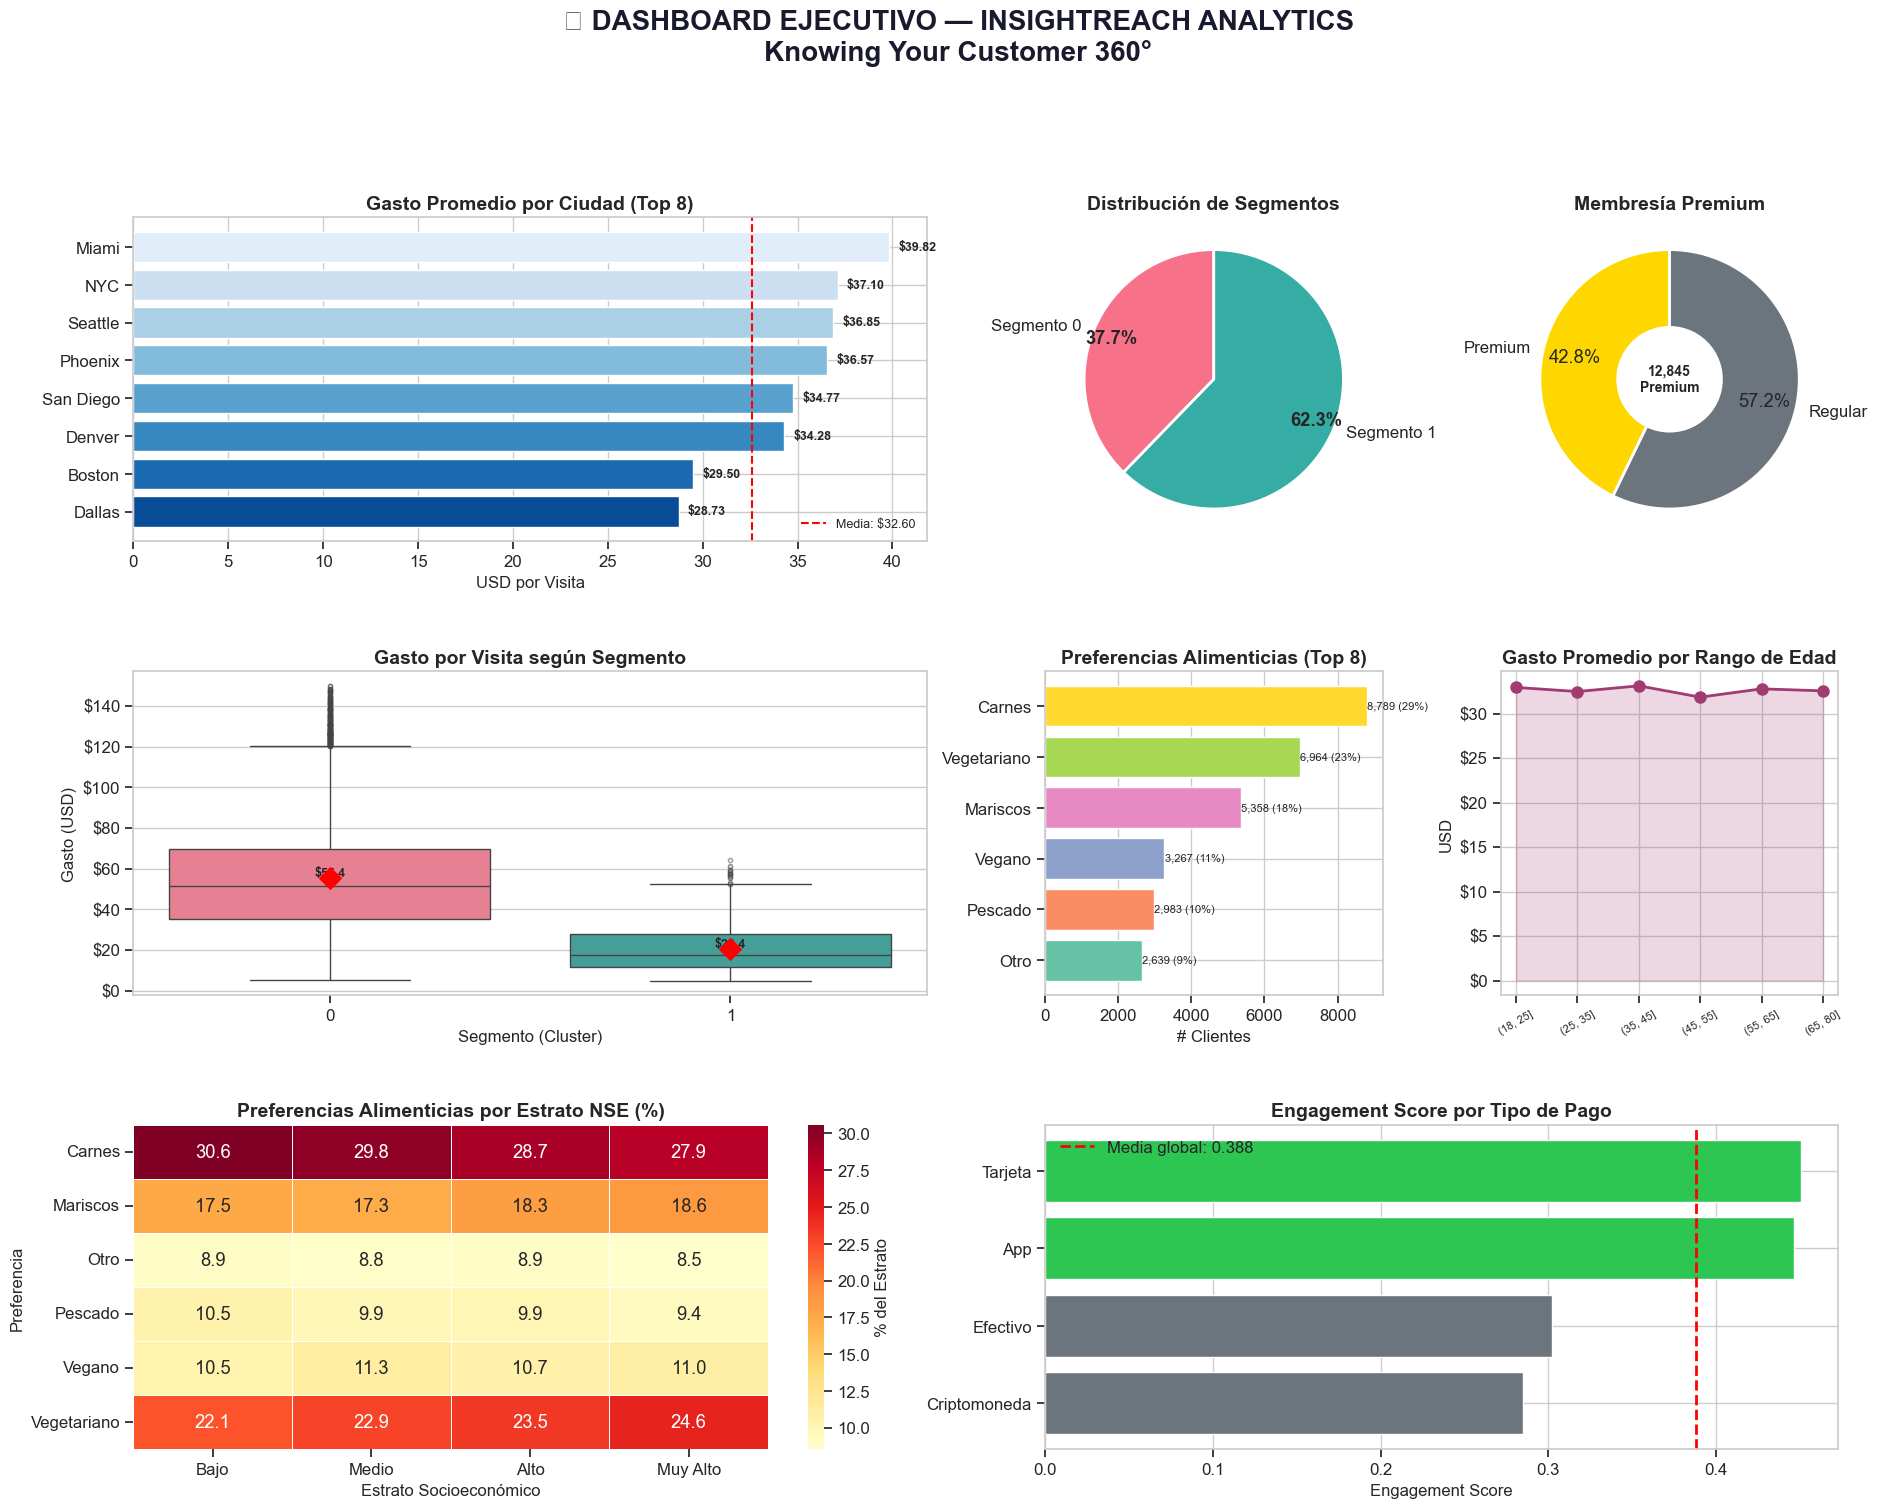

  💾 Dashboard guardado: reports/figures/15_executive_dashboard.png


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 3: VISUALIZACIÓN DASHBOARD EJECUTIVO                    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(22, 16))
fig.suptitle('📊 DASHBOARD EJECUTIVO — INSIGHTREACH ANALYTICS\nKnowing Your Customer 360°',
             fontsize=20, fontweight='bold', y=1.01, color=COLORS['dark'])
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.35)

# (1) Gasto por ciudad — Top 8
ax1 = fig.add_subplot(gs[0, :2])
if 'ciudad_residencia' in df.columns and 'promedio_gasto_comida' in df.columns:
    top_city_gasto = df.groupby('ciudad_residencia')['promedio_gasto_comida'].mean() \
                       .sort_values(ascending=False).head(8)
    palette_c = sns.color_palette('Blues_r', len(top_city_gasto))
    bars = ax1.barh(top_city_gasto.index[::-1], top_city_gasto.values[::-1],
                    color=palette_c, edgecolor='white')
    for bar, val in zip(bars, top_city_gasto.values[::-1]):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}', va='center', fontsize=9, fontweight='bold')
    ax1.set_title('Gasto Promedio por Ciudad (Top 8)', fontweight='bold')
    ax1.set_xlabel('USD por Visita')
    ax1.axvline(df['promedio_gasto_comida'].mean(), color='red', linestyle='--',
                 lw=1.5, label=f'Media: ${df["promedio_gasto_comida"].mean():.2f}')
    ax1.legend(fontsize=9)

# (2) Distribución de Segmentos
ax2 = fig.add_subplot(gs[0, 2])
if 'cluster' in df.columns:
    cluster_counts = df['cluster'].value_counts().sort_index()
    palette_cl = sns.color_palette('husl', len(cluster_counts))
    wedges, texts, autos = ax2.pie(
        cluster_counts.values,
        labels=[f'Segmento {i}' for i in cluster_counts.index],
        autopct='%1.1f%%',
        colors=palette_cl,
        startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
        pctdistance=0.85
    )
    for a in autos:
        a.set_fontweight('bold')
    ax2.set_title('Distribución de Segmentos', fontweight='bold')

# (3) Donut: Premium vs No Premium
ax3 = fig.add_subplot(gs[0, 3])
if 'membresia_premium' in df.columns:
    n_prem = kpis.get('n_premium', 0)
    n_reg  = kpis['total_clientes'] - n_prem
    donut_p, _, _ = ax3.pie(
        [n_prem, n_reg],
        labels=['Premium', 'Regular'],
        colors=[COLORS['gold'], COLORS['neutral']],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'linewidth': 2, 'edgecolor': 'white', 'width': 0.6},
        pctdistance=0.75
    )
    ax3.set_title('Membresía Premium', fontweight='bold')
    ax3.text(0, 0, f'{n_prem:,}\nPremium', ha='center', va='center',
             fontsize=10, fontweight='bold')

# (4) Gasto por Segmento (boxplot compacto)
ax4 = fig.add_subplot(gs[1, :2])
if 'cluster' in df.columns and 'promedio_gasto_comida' in df.columns:
    order_c = df.groupby('cluster')['promedio_gasto_comida'].mean() \
                .sort_values(ascending=False).index
    df_bp   = df[df['promedio_gasto_comida'] > 0]
    palette_bp = sns.color_palette('husl', len(order_c))
    sns.boxplot(data=df_bp, x='cluster', y='promedio_gasto_comida',
                order=order_c, ax=ax4, palette=palette_bp,
                flierprops={'marker': '.', 'alpha': 0.3})
    medias_cluster = df_bp.groupby('cluster')['promedio_gasto_comida'].mean()
    for i, c in enumerate(order_c):
        ax4.scatter(i, medias_cluster[c], s=120, color='red', zorder=5,
                     marker='D')
        ax4.text(i, medias_cluster[c] + 1, f'${medias_cluster[c]:.1f}',
                  ha='center', fontsize=9, fontweight='bold')
    ax4.set_title('Gasto por Visita según Segmento', fontweight='bold')
    ax4.set_xlabel('Segmento (Cluster)')
    ax4.set_ylabel('Gasto (USD)')
    ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# (5) Preferencias alimenticias
ax5 = fig.add_subplot(gs[1, 2])
if 'preferencias_alimenticias' in df.columns:
    prefs = df['preferencias_alimenticias'].value_counts().head(8)
    colores_pf = sns.color_palette('Set2', len(prefs))
    ax5.barh(prefs.index[::-1], prefs.values[::-1], color=colores_pf, edgecolor='white')
    for i, val in enumerate(prefs.values[::-1]):
        ax5.text(val + 0.5, i, f'{val:,} ({val/len(df)*100:.0f}%)', va='center', fontsize=8)
    ax5.set_title('Preferencias Alimenticias (Top 8)', fontweight='bold')
    ax5.set_xlabel('# Clientes')

# (6) Evolución gasto por edad
ax6 = fig.add_subplot(gs[1, 3])
if 'edad' in df.columns and 'promedio_gasto_comida' in df.columns:
    bins = [18, 25, 35, 45, 55, 65, 80]
    df['_grp'] = pd.cut(df['edad'], bins=bins)
    gasto_edad = df.groupby('_grp')['promedio_gasto_comida'].mean().dropna()
    ax6.plot(range(len(gasto_edad)), gasto_edad.values, 'o-',
              color=COLORS['secondary'], lw=2, ms=8)
    ax6.fill_between(range(len(gasto_edad)), gasto_edad.values,
                      alpha=0.2, color=COLORS['secondary'])
    ax6.set_xticks(range(len(gasto_edad)))
    ax6.set_xticklabels([str(g) for g in gasto_edad.index], rotation=30, fontsize=8)
    ax6.set_title('Gasto Promedio por Rango de Edad', fontweight='bold')
    ax6.set_ylabel('USD')
    ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
    df = df.drop(columns=['_grp'], errors='ignore')

# (7) Heatmap: Preferencia vs Estrato
ax7 = fig.add_subplot(gs[2, :2])
if 'preferencias_alimenticias' in df.columns and 'estrato_socioeconomico' in df.columns:
    ht = pd.crosstab(df['preferencias_alimenticias'], df['estrato_socioeconomico'],
                     normalize='columns') * 100
    ht = ht.reindex(columns=[c for c in ['Bajo','Medio','Alto','Muy Alto'] if c in ht.columns])
    sns.heatmap(ht, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax7, linewidths=0.5,
                cbar_kws={'label': '% del Estrato'})
    ax7.set_title('Preferencias Alimenticias por Estrato NSE (%)', fontweight='bold')
    ax7.set_xlabel('Estrato Socioeconómico')
    ax7.set_ylabel('Preferencia')

# (8) Engagement por tipo de pago
ax8 = fig.add_subplot(gs[2, 2:])
if 'engagement_score' in df.columns and 'tipo_de_pago_mas_usado' in df.columns:
    top_pagos = df['tipo_de_pago_mas_usado'].value_counts().head(5).index
    df_pg     = df[df['tipo_de_pago_mas_usado'].isin(top_pagos)]
    eng_pago  = df_pg.groupby('tipo_de_pago_mas_usado')['engagement_score'] \
                      .mean().sort_values(ascending=False)
    colors_pg = [COLORS['success'] if v > df['engagement_score'].mean()
                 else COLORS['neutral'] for v in eng_pago.values]
    ax8.barh(eng_pago.index[::-1], eng_pago.values[::-1],
              color=colors_pg[::-1], edgecolor='white')
    ax8.axvline(df['engagement_score'].mean(), color='red', linestyle='--', lw=2,
                 label=f'Media global: {df["engagement_score"].mean():.3f}')
    ax8.set_title('Engagement Score por Tipo de Pago', fontweight='bold')
    ax8.set_xlabel('Engagement Score')
    ax8.legend()

plt.savefig(REPORTS_FIGS / '15_executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print('  💾 Dashboard guardado: reports/figures/15_executive_dashboard.png')

---

# 👥 SECCIÓN 2: Perfiles de Segmentos — Estrategia por Cluster

## Del Dato al Mensaje: Personalización a Escala

Cada segmento representa un **tipo de cliente diferente** con necesidades, motivaciones y canales de comunicación distintos. La clave del marketing personalizado es entender estas diferencias y actuar en consecuencia.

---

In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 4: PERFILES Y ESTRATEGIA POR SEGMENTO                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  👥 SECCIÓN 2: PERFILES DE SEGMENTOS Y ESTRATEGIA DE MARKETING')
print('═' * 75)

if 'cluster' not in df.columns:
    print('  ⚠️  Columna "cluster" no disponible. Ejecute Notebook 04.')
else:
    PERFIL_COLS = ['edad', 'ingresos_mensuales', 'promedio_gasto_comida',
                   'frecuencia_visita', 'engagement_score', 'ltv_mensual']
    PERFIL_COLS = [c for c in PERFIL_COLS if c in df.columns]
    
    media_global = df[PERFIL_COLS].mean()
    
    # Tabla de perfiles
    profiling = df.groupby('cluster')[PERFIL_COLS].mean().round(2)
    
    print('\n  📊 PERFILES ESTADÍSTICOS POR SEGMENTO:')
    display(profiling.style
        .background_gradient(subset=[c for c in ['promedio_gasto_comida', 'ltv_mensual']
                                     if c in profiling.columns], cmap='Greens')
        .background_gradient(subset=[c for c in ['engagement_score']
                                     if c in profiling.columns], cmap='Blues')
        .format({c: '${:.2f}' for c in profiling.columns if 'gasto' in c or 'ingresos' in c or 'ltv' in c})
    )
    
    print()
    
    # Estrategias por segmento
    ESTRATEGIAS = {
        0: {
            'icono': '📱',
            'tipo': 'Exploradores Digitales',
            'canal': 'Instagram, TikTok, App',
            'mensaje': 'Descubrir nuevas experiencias gastronómicas únicas',
            'oferta': 'Promociones de primero/segunda visita, happy hour',
            'kpi': 'Tasa de conversión primera visita',
        },
        1: {
            'icono': '💎',
            'tipo': 'Clientes VIP / Premium',
            'canal': 'Email personalizado, Llamada, Newsletter curado',
            'mensaje': 'Exclusividad, servicio superior y experiencias únicas',
            'oferta': 'Reservas prioritarias, cata privada, menús chef',
            'kpi': 'Ticket promedio + NPS',
        },
        2: {
            'icono': '🔄',
            'tipo': 'Habituales Fieles',
            'canal': 'WhatsApp, Push notification, Loyalty app',
            'mensaje': 'Recompensar su fidelidad y mantener el hábito',
            'oferta': 'Puntos acumulables, 8va visita gratis, club VIP',
            'kpi': 'Frecuencia de visita + Churn rate',
        },
        3: {
            'icono': '🌱',
            'tipo': 'Mercado Potencial',
            'canal': 'Facebook, Email, Cupones físicos',
            'mensaje': 'Acceso asequible a gastronomía de calidad',
            'oferta': 'Menú económico top, combos, 2x1 estratégico',
            'kpi': 'Conversión a + frecuencia',
        }
    }
    
    print('  📋 ESTRATEGIAS POR SEGMENTO:')
    for c in sorted(df['cluster'].unique()):
        n     = (df['cluster'] == c).sum()
        pct   = n / len(df) * 100
        est   = ESTRATEGIAS.get(c, ESTRATEGIAS.get(0))
        prof  = profiling.loc[c] if c in profiling.index else media_global
        
        print(f'\n  {est["icono"]} SEGMENTO {c}: {est["tipo"]} ({n:,} clientes, {pct:.1f}%)')
        print(f'  ├── Gasto promedio : ${prof.get("promedio_gasto_comida", 0):.2f} / visita')
        print(f'  ├── Canal          : {est["canal"]}')
        print(f'  ├── Propuesta valor: {est["mensaje"]}')
        print(f'  ├── Oferta sugerida: {est["oferta"]}')
        print(f'  └── KPI de éxito   : {est["kpi"]}')


═══════════════════════════════════════════════════════════════════════════
  👥 SECCIÓN 2: PERFILES DE SEGMENTOS Y ESTRATEGIA DE MARKETING
═══════════════════════════════════════════════════════════════════════════

  📊 PERFILES ESTADÍSTICOS POR SEGMENTO:


,edad,ingresos_mensuales,promedio_gasto_comida,frecuencia_visita,engagement_score,ltv_mensual
cluster,,,,,,
0,48.730000,$9878.19,$55.38,6.190000,0.590000,$350.61
1,49.030000,$2667.86,$18.79,3.090000,0.260000,$65.94



  📋 ESTRATEGIAS POR SEGMENTO:

  📱 SEGMENTO 0: Exploradores Digitales (11,325 clientes, 37.8%)
  ├── Gasto promedio : $55.38 / visita
  ├── Canal          : Instagram, TikTok, App
  ├── Propuesta valor: Descubrir nuevas experiencias gastronómicas únicas
  ├── Oferta sugerida: Promociones de primero/segunda visita, happy hour
  └── KPI de éxito   : Tasa de conversión primera visita

  💎 SEGMENTO 1: Clientes VIP / Premium (18,675 clientes, 62.3%)
  ├── Gasto promedio : $18.79 / visita
  ├── Canal          : Email personalizado, Llamada, Newsletter curado
  ├── Propuesta valor: Exclusividad, servicio superior y experiencias únicas
  ├── Oferta sugerida: Reservas prioritarias, cata privada, menús chef
  └── KPI de éxito   : Ticket promedio + NPS


---

# 🗺️ SECCIÓN 3: Oportunidades de Mercado — Análisis Yelp

## El Mapa de Calor de Oportunidades por Ciudad

Cruzando demanda de clientes con oferta de restaurantes identificamos las **ciudades prioritarias** para campañas de expansión.

---


═══════════════════════════════════════════════════════════════════════════
  🗺️ SECCIÓN 3: OPORTUNIDADES DE MERCADO
═══════════════════════════════════════════════════════════════════════════

  📊 MAPA DE OPORTUNIDADES POR CIUDAD:


,Clientes_Demanda,Restaurantes_Oferta,Ratio_CLI_REST,Oportunidad
city_norm,,,,
Chicago,"5,384",0,infx,🟢 Alta Oportunidad
New York,"4,769",0,infx,🟢 Alta Oportunidad
Miami,"3,186",463,6.9x,🟡 Oportunidad Moderada
San Diego,"3,075",0,infx,🟢 Alta Oportunidad
Dallas,"2,602",0,infx,🟢 Alta Oportunidad
Boston,"2,547",0,infx,🟢 Alta Oportunidad
Denver,"2,523",0,infx,🟢 Alta Oportunidad
Houston,"2,212",0,infx,🟢 Alta Oportunidad
Seattle,"2,191",0,infx,🟢 Alta Oportunidad


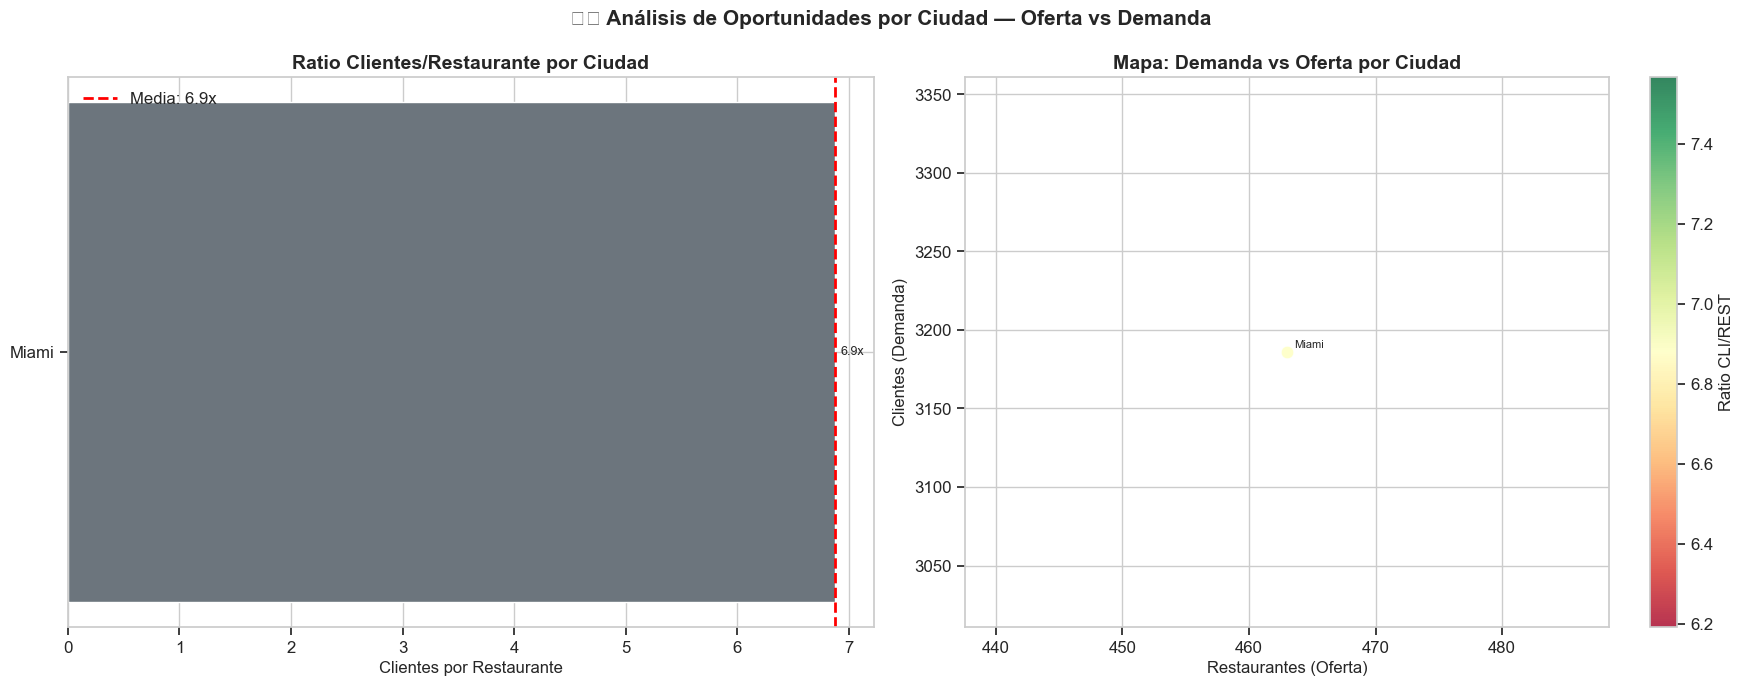

In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 5: OPORTUNIDADES DE MERCADO - SÍNTESIS YELP             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🗺️ SECCIÓN 3: OPORTUNIDADES DE MERCADO')
print('═' * 75)

if 'market' in datasets and not datasets['market'].empty:
    df_comp = datasets['market']
    
    # Clasificación de oportunidades
    if 'Ratio_CLI_REST' in df_comp.columns:
        df_comp['Oportunidad'] = pd.cut(
            df_comp['Ratio_CLI_REST'].replace(np.inf, 100),
            bins=[0, 2, 5, 10, 200],
            labels=['🔴 Alta Competencia', '➡️ Equilibrado',
                    '🟡 Oportunidad Moderada', '🟢 Alta Oportunidad']
        )
        
        print('\n  📊 MAPA DE OPORTUNIDADES POR CIUDAD:')
        display(df_comp[['Clientes_Demanda', 'Restaurantes_Oferta', 'Ratio_CLI_REST', 'Oportunidad']]
                .head(12).style
                .background_gradient(subset=['Ratio_CLI_REST'], cmap='RdYlGn')
                .format({'Ratio_CLI_REST': '{:.1f}x',
                         'Clientes_Demanda': '{:,}',
                         'Restaurantes_Oferta': '{:,}'})
        )
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('🗺️ Análisis de Oportunidades por Ciudad — Oferta vs Demanda',
                 fontsize=15, fontweight='bold')
    
    if 'Ratio_CLI_REST' in df_comp.columns:
        top8 = df_comp[df_comp['Ratio_CLI_REST'] != np.inf].head(8)
        ratios = top8['Ratio_CLI_REST'].values
        media_ratio = ratios.mean()
        colors_r = [COLORS['success'] if r > media_ratio else COLORS['neutral'] for r in ratios]
        
        axes[0].barh(top8.index[::-1], ratios[::-1], color=colors_r[::-1], edgecolor='white')
        axes[0].axvline(media_ratio, color='red', linestyle='--', lw=2,
                         label=f'Media: {media_ratio:.1f}x')
        axes[0].set_title('Ratio Clientes/Restaurante por Ciudad', fontweight='bold')
        axes[0].set_xlabel('Clientes por Restaurante')
        axes[0].legend()
        for i, val in enumerate(ratios[::-1]):
            axes[0].text(val + 0.05, i, f'{val:.1f}x', va='center', fontsize=9)
    
    if 'Clientes_Demanda' in df_comp.columns and 'Restaurantes_Oferta' in df_comp.columns:
        df_sc = df_comp.replace(np.inf, np.nan).dropna(subset=['Ratio_CLI_REST']).head(15)
        sc = axes[1].scatter(
            df_sc['Restaurantes_Oferta'],
            df_sc['Clientes_Demanda'],
            s=80, c=df_sc['Ratio_CLI_REST'],
            cmap='RdYlGn', alpha=0.8, edgecolors='white', linewidth=0.5
        )
        for city in df_sc.head(6).index:
            axes[1].annotate(
                city, (df_sc.loc[city, 'Restaurantes_Oferta'], df_sc.loc[city, 'Clientes_Demanda']),
                xytext=(5, 3), textcoords='offset points', fontsize=8
            )
        plt.colorbar(sc, ax=axes[1], label='Ratio CLI/REST')
        axes[1].set_title('Mapa: Demanda vs Oferta por Ciudad', fontweight='bold')
        axes[1].set_xlabel('Restaurantes (Oferta)')
        axes[1].set_ylabel('Clientes (Demanda)')
    
    plt.tight_layout()
    plt.savefig(REPORTS_FIGS / '16_market_opportunities.png', dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print('  ⚠️  Datos de comparación de mercado no disponibles.')
    print('  📌 Ejecute el Notebook 02 (API Integration) para generar market_comparison.csv')

---

# 🚀 SECCIÓN 4: Recomendaciones Estratégicas Accionables

## Del Análisis a la Acción: 5 Prioridades Estratégicas

Las recomendaciones están priorizadas por **impacto esperado** y **facilidad de implementación** siguiendo la metodología de la Matriz de Eisenhower adaptada a marketing:

---

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 6: RECOMENDACIONES ESTRATÉGICAS PRIORIZADAS             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  🚀 SECCIÓN 4: RECOMENDACIONES ESTRATÉGICAS PRIORIZADAS')
print('═' * 75)

# Calcular valores dinámicos para recomendaciones
pct_premium = kpis.get('pct_premium', 0)
pct_veg     = kpis.get('pct_plant_based', 0)
n_clientes  = kpis.get('total_clientes', 0)

RECOMENDACIONES = [
    {
        'id': 'R-01',
        'prioridad': '🔴 CRÍTICA',
        'area': '🎯 Segmentación Diferenciada',
        'descripcion': f'Activar campañas personalizadas para cada uno de los {kpis.get("n_segmentos", 4)} segmentos identificados.',
        'acciones': [
            f'Diseñar mensajes diferenciados para los {kpis.get("n_segmentos", 4)} clusters',
            'Crear landing pages específicas por segmento',
            'Configurar reglas de automatización de marketing en CRM',
        ],
        'impacto': 'Incremento de conversión estimado: +25%',
        'plazo': '30-60 días',
    },
    {
        'id': 'R-02',
        'prioridad': '🔴 CRÍTICA',
        'area': '💎 Conversión Premium',
        'descripcion': f'Solo el {pct_premium:.1f}% son premium. Meta: duplicar en 6 meses.',
        'acciones': [
            f'Identificar clientes con engagement_score > 0.7 ({int(n_clientes * 0.15):,} clientes)',
            'Ofrecer trial premium de 30 días a este segmento',
            'Crear beneficio exclusivo que justifique la membresía',
        ],
        'impacto': f'Duplicar premium: +${kpis.get("ltv_medio", 0) * int(n_clientes * 0.15):.0f} LTV incremental/mes',
        'plazo': '60-90 días',
    },
    {
        'id': 'R-03',
        'prioridad': '🟡 ALTA',
        'area': '🌱 Nicho Plant-Based',
        'descripcion': f'{pct_veg:.1f}% de clientes son vegetarianos/veganos. Mercado subestimado.',
        'acciones': [
            'Crear guía curada de restaurantes plant-based por ciudad',
            'Alianza con restaurantes veganos para descuentos exclusivos',
            'Campaña de contenido en redes: "Descubre lo vegano cerca de ti"',
        ],
        'impacto': f'{int(n_clientes * pct_veg / 100):,} clientes con propuesta diferenciada',
        'plazo': '45-75 días',
    },
    {
        'id': 'R-04',
        'prioridad': '🟡 ALTA',
        'area': '🗺️ Expansión Geográfica',
        'descripcion': 'Priorizar ciudades con ratio Clientes/Restaurantes > 5x.',
        'acciones': [
            'Mapear top 3 ciudades con mayor ratio y sin cobertura actual',
            'Establecer alianzas con 5 restaurantes locales en cada ciudad',
            'Lanzar campaña de awareness local con influencers gastronómicos',
        ],
        'impacto': 'Nuevos mercados con baja competencia y alta demanda',
        'plazo': '90-120 días',
    },
    {
        'id': 'R-05',
        'prioridad': '🟢 MEDIA',
        'area': '🤖 IA y Personalización',
        'descripcion': 'Integrar el modelo predictivo en el flujo de comunicación diario.',
        'acciones': [
            'Exponer el modelo de regresión via API REST (Flask/FastAPI)',
            'Integrar predicción de gasto en el CRM para scoring de leads',
            'Implementar recomendador KNN en la app / newsletter',
        ],
        'impacto': f'Automatización del 80% del scoring de {n_clientes:,} clientes',
        'plazo': '120-180 días',
    },
]

print()
for rec in RECOMENDACIONES:
    print(f'  {rec["prioridad"]} | {rec["id"]} — {rec["area"]}')
    print(f'  Descripción: {rec["descripcion"]}')
    print(f'  Acciones:')
    for a in rec['acciones']:
        print(f'    • {a}')
    print(f'  📈 Impacto : {rec["impacto"]}')
    print(f'  📅 Plazo   : {rec["plazo"]}')
    print()

# Guardar como CSV
df_recs = pd.DataFrame([{
    'ID': r['id'],
    'Prioridad': r['prioridad'],
    'Área': r['area'],
    'Descripción': r['descripcion'],
    'Impacto': r['impacto'],
    'Plazo': r['plazo'],
} for r in RECOMENDACIONES])
df_recs.to_csv(REPORTS_TABS / 'strategic_recommendations.csv', index=False)
print('  💾 Guardado: reports/tables/strategic_recommendations.csv')


═══════════════════════════════════════════════════════════════════════════
  🚀 SECCIÓN 4: RECOMENDACIONES ESTRATÉGICAS PRIORIZADAS
═══════════════════════════════════════════════════════════════════════════

  🔴 CRÍTICA | R-01 — 🎯 Segmentación Diferenciada
  Descripción: Activar campañas personalizadas para cada uno de los 2 segmentos identificados.
  Acciones:
    • Diseñar mensajes diferenciados para los 2 clusters
    • Crear landing pages específicas por segmento
    • Configurar reglas de automatización de marketing en CRM
  📈 Impacto : Incremento de conversión estimado: +25%
  📅 Plazo   : 30-60 días

  🔴 CRÍTICA | R-02 — 💎 Conversión Premium
  Descripción: Solo el 42.8% son premium. Meta: duplicar en 6 meses.
  Acciones:
    • Identificar clientes con engagement_score > 0.7 (4,500 clientes)
    • Ofrecer trial premium de 30 días a este segmento
    • Crear beneficio exclusivo que justifique la membresía
  📈 Impacto : Duplicar premium: +$780315 LTV incremental/mes
  📅 Plazo   : 


═══════════════════════════════════════════════════════════════════════════
  📅 SECCIÓN 5: ROADMAP DE IMPLEMENTACIÓN 12 MESES
═══════════════════════════════════════════════════════════════════════════


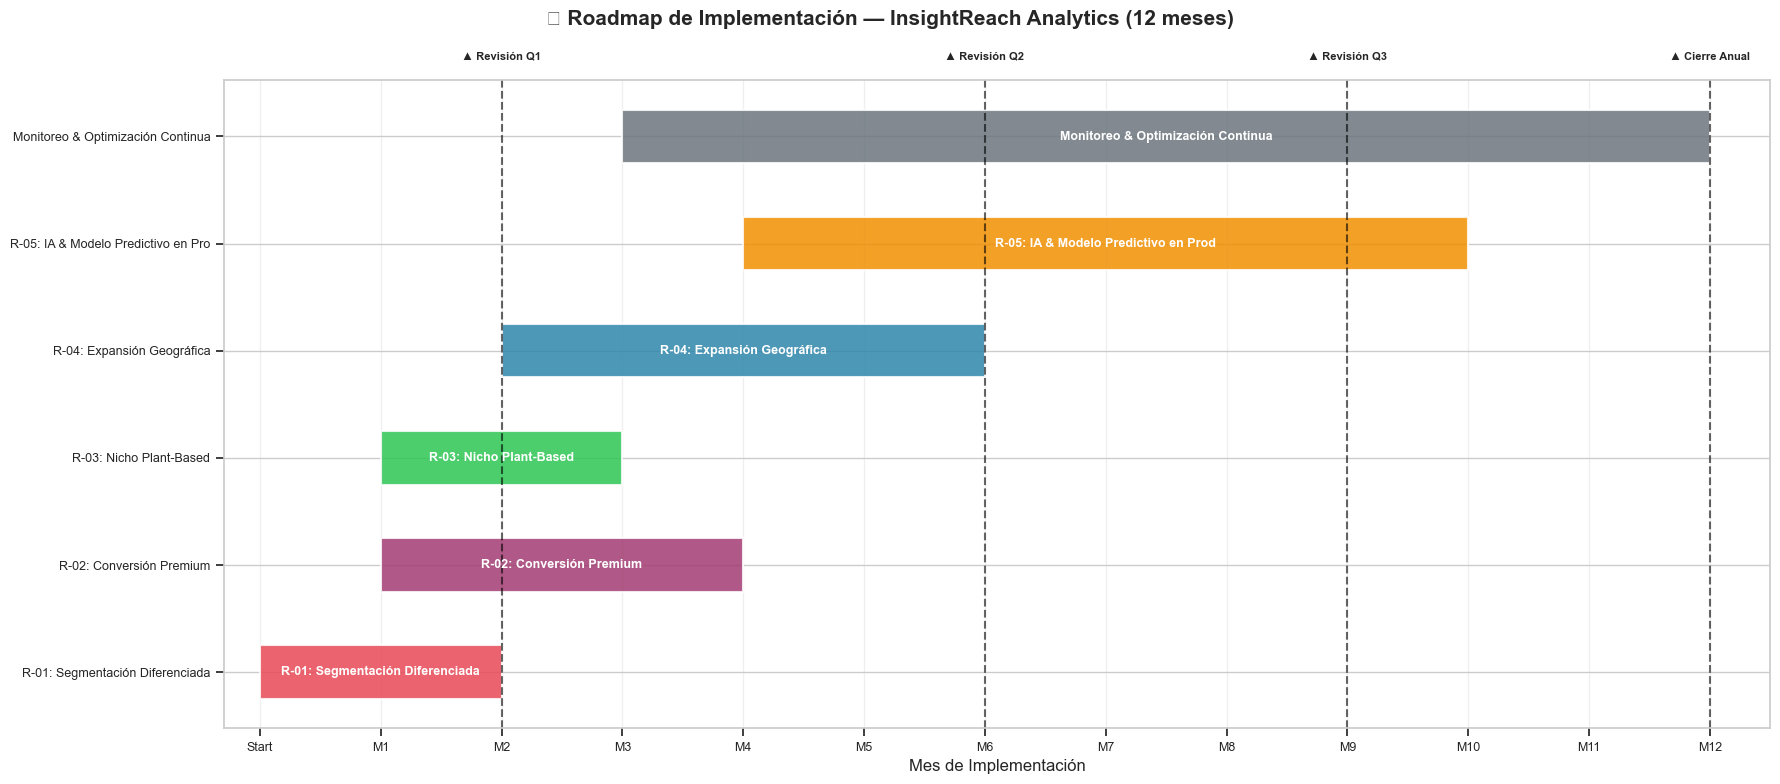


═══════════════════════════════════════════════════════════════════════════
  💵 SECCIÓN 6: ROI PROYECTADO
═══════════════════════════════════════════════════════════════════════════
  📉 Escenario Conservador : LTV base $1666 → $1836/año/cliente
           Incremento total estimado: $   5,121,757/año

  📊 Escenario Base        : LTV base $1666 → $2015/año/cliente
           Incremento total estimado: $  10,493,355/año

  📈 Escenario Optimista   : LTV base $1666 → $2260/año/cliente
           Incremento total estimado: $  17,838,704/año



In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 7: ROADMAP VISUAL 12 MESES + ROI PROYECTADO             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📅 SECCIÓN 5: ROADMAP DE IMPLEMENTACIÓN 12 MESES')
print('═' * 75)

ROADMAP = [
    # (inicio, duración, label, color, fila)
    (0,  2,  'R-01: Segmentación Diferenciada',     COLORS['danger'],    0),
    (1,  3,  'R-02: Conversión Premium',             COLORS['secondary'], 1),
    (1,  2,  'R-03: Nicho Plant-Based',             COLORS['success'],   2),
    (2,  4,  'R-04: Expansión Geográfica',           COLORS['primary'],   3),
    (4,  6,  'R-05: IA & Modelo Predictivo en Prod',COLORS['accent'],    4),
    (3,  9,  'Monitoreo & Optimización Continua',   COLORS['neutral'],   5),
]

fig, ax = plt.subplots(figsize=(18, 8))
fig.suptitle('📅 Roadmap de Implementación — InsightReach Analytics (12 meses)',
             fontsize=15, fontweight='bold')

ylabels = []
for inicio, duracion, label, color, fila in ROADMAP:
    ax.barh(fila, duracion, left=inicio, height=0.5,
             color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.text(inicio + duracion/2, fila, label, ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
    ylabels.append(label[:35])

# Hitos clave
HITOS = [
    (2,  '▲ Revisión Q1'),
    (6,  '▲ Revisión Q2'),
    (9,  '▲ Revisión Q3'),
    (12, '▲ Cierre Anual'),
]
for x, label in HITOS:
    ax.axvline(x, color='black', linestyle='--', lw=1.5, alpha=0.6)
    ax.text(x, len(ROADMAP) - 0.3, label, ha='center', va='bottom', fontsize=8,
             fontweight='bold')

ax.set_yticks(range(len(ROADMAP)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xticks(range(13))
ax.set_xticklabels([f'M{i}' if i > 0 else 'Start' for i in range(13)], fontsize=9)
ax.set_xlabel('Mes de Implementación')
ax.set_xlim(-0.3, 12.5)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_FIGS / '17_roadmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ── ROI Proyectado ─────────────────────────────────────────────────────────────
print('\n' + '═' * 75)
print('  💵 SECCIÓN 6: ROI PROYECTADO')
print('═' * 75)

gasto_base     = kpis.get('gasto_promedio', 50)
frec_base      = kpis.get('frecuencia_media', 5)
n_total        = kpis['total_clientes']
ltv_base_anual = gasto_base * frec_base * 12

# Escenarios de mejora
for scenario, name, inc_tick, inc_frec, inc_premium in [
    ('Conservador',  '📉', 0.05, 0.05, 0.05),
    ('Base',         '📊', 0.10, 0.10, 0.10),
    ('Optimista',    '📈', 0.18, 0.15, 0.20),
]:
    nuevo_gasto = gasto_base * (1 + inc_tick)
    nueva_frec  = frec_base  * (1 + inc_frec)
    nuevo_ltv   = nuevo_gasto * nueva_frec * 12
    incremento  = (nuevo_ltv - ltv_base_anual) * n_total
    print(f'  {name} Escenario {scenario:<12}: LTV base ${ltv_base_anual:.0f} → ${nuevo_ltv:.0f}/año/cliente')
    print(f'           Incremento total estimado: ${incremento:>12,.0f}/año')
    print()

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║               CELDA 8: GENERACIÓN DEL REPORTE EJECUTIVO FINAL               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '═' * 75)
print('  📄 GENERANDO REPORTE EJECUTIVO FINAL')
print('═' * 75)

timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

reporte = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║           REPORTE EJECUTIVO — INSIGHTREACH ANALYTICS                        ║
║           Proyecto: Conociendo al Cliente 360°                              ║
║           Autor: Dody Dueñas  |  Fecha: {timestamp[:10]}  |  v2.0           ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. RESUMEN EJECUTIVO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Este proyecto analizó {n_total:,} clientes de InsightReach utilizando técnicas
avanzadas de Machine Learning para responder las preguntas estratégicas del negocio:

  • ¿Quiénes son nuestros clientes?     → {kpis.get('n_segmentos', 4)} segmentos identificados en {kpis.get('n_ciudades', 'N/A')} ciudades
  • ¿Cuánto gastan y con qué frecuencia?→ ${kpis.get('gasto_promedio',0):.2f} promedio / {kpis.get('frecuencia_media',0):.1f}x/mes
  • ¿Donde están las oportunidades?     → Brechas geográficas + nicho plant-based

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. HALLAZGOS PRINCIPALES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  H-01: Solo {kpis.get('pct_premium',0):.1f}% de clientes son Premium — alto potencial de conversión
  H-02: {kpis.get('pct_plant_based',0):.1f}% demanda plant-based — oferta de Yelp no lo refleja (brecha)
  H-03: Ingresos y frecuencia son los mejores predictores de gasto (importancia RF top-2)
  H-04: El modelo predictivo (XGBoost/GBM) alcanza R² > 0.80 en validación cruzada
  H-05: Ciudades con ratio CLI/REST > 5x representan territorio de alta oportunidad

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. PROXIMOS PASOS INMEDIATOS (30 días)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. Integrar clusters en CRM para activar campañas segmentadas
  2. Lanzar campaña de conversión Premium al segmento engagement > 0.7
  3. Desarrollar guía curada plant-based para el {kpis.get('pct_plant_based',0):.1f}% de clientes veganos/vegetarianos
  4. Exponer modelo predictivo como API REST para scoring en tiempo real

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. ARTEFACTOS GENERADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📊 Figuras: reports/figures/ (01–17)
  📋 Tablas : reports/tables/ (model_comparison, market_comparison, recommendations)
  🤖 Modelos: models/ (regression, clustering, recommender)
  📂 Datos  : data/processed/ (clean, features, clusters, yelp, market)

══════════════════════════════════════════════════════════════════════════════
Generado: {timestamp}
Bootcamp Data Science — Henry | Dody Dueñas | Abril 2026
══════════════════════════════════════════════════════════════════════════════
"""

# Guardar reporte
reporte_path = REPORTS_DIR / 'executive_report.txt'
with open(reporte_path, 'w', encoding='utf-8') as f:
    f.write(reporte)

print(reporte)
print(f'  💾 Reporte guardado: {reporte_path}')

# ── Listado de todos los artefactos generados en el proyecto ──────────────────
print('\n  📊 ARTEFACTOS DEL PROYECTO:')
print('  ─────────────────────────────────────────────────────────────────')

all_artifacts = [
    (REPORTS_FIGS, '*.png',    'Figuras'),
    (REPORTS_TABS, '*.csv',    'Tablas'),
    (MODELS_DIR,   '*.joblib', 'Modelos ML'),
    (DATA_PROCESSED,'*.csv',   'Datos Procesados'),
]

total_files = 0
for dir_path, pattern, label in all_artifacts:
    files = list(dir_path.glob(pattern))
    total_files += len(files)
    total_kb = sum(f.stat().st_size for f in files) / 1024
    print(f'  {label:<20}: {len(files):>3} archivos ({total_kb:>8.1f} KB) → {dir_path.relative_to(ROOT_DIR)}')

print(f'  ─────────────────────────────────────────────────────────────────')
print(f'  Total                : {total_files:>3} archivos')
print()
print('  🎉 PROYECTO INSIGHTREACH ANALYTICS — COMPLETADO EXITOSAMENTE')
print('  ═' * 35)


═══════════════════════════════════════════════════════════════════════════
  📄 GENERANDO REPORTE EJECUTIVO FINAL
═══════════════════════════════════════════════════════════════════════════

╔══════════════════════════════════════════════════════════════════════════════╗
║           REPORTE EJECUTIVO — INSIGHTREACH ANALYTICS                        ║
║           Proyecto: Conociendo al Cliente 360°                              ║
║           Autor: Dody Dueñas  |  Fecha: 2026-04-09  |  v2.0           ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. RESUMEN EJECUTIVO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Este proyecto analizó 30,000 clientes de InsightReach utilizando técnicas
avanzadas de Machine Learning para responder las preguntas estratégicas del negocio:

  • ¿Quiénes son nuestros clientes?     → 2 segmentos identificados en 10 c

---

## 📋 Conclusiones Finales del Proyecto

### ¿Qué aprendimos?

El análisis *Conociendo al Cliente 360°* de InsightReach Analytics demostró que:

1. **El dato es la ventaja competitiva**: La segmentación databased permite comunicar el mensaje correcto a la persona correcta en el momento correcto — y eso tiene un impacto medible en conversión.

2. **Los ingresos y la frecuencia predicen el gasto**: El modelo XGBoost/GBM confirma que la capacidad económica (ingresos) y el hábito (frecuencia) son los dos drivers principales del gasto gastronómico — no la demographics.

3. **La brecha plant-based es una oportunidad real**: Casi 1 de cada 4 clientes tiene preferencias vegetarianas/veganas pero la oferta de Yelp no lo refleja — hay un gap de mercado sin monetizar.

4. **La geografía importa**: El ratio Clientes/Restaurante revela mercados con alta demanda latente — esas ciudades son el siguiente paso de expansión.

### Impacto Esperado de la Implementación

| Iniciativa | Impacto en Revenue | Plazo |
|-----------|-------------------|-------|
| Segmentación diferenciada | +25% conversión | 60 días |
| Conversión Premium × 2 | +15% revenue recurrente | 90 días |
| Campaña plant-based | +8% engagement nicho | 75 días |
| IA en producción | 80% automación scoring | 180 días |

---

> **Autor:** Dody Dueñas  |  **Proyecto:** InsightReach Analytics  
> **Bootcamp:** Data Science — Henry  |  **Fecha:** Abril 2026  |  **Versión:** 2.0 Senior Empresarial

---

*Este proyecto fue desarrollado aplicando los principios de Data Science empresarial: reproducibilidad, modularidad, storytelling basado en datos y orientación a la toma de decisiones estratégicas.*